<a href="https://colab.research.google.com/github/pamritha25/ML-and-DL-Projects/blob/main/cervical%20cancer/cervical_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem statement**

Cervical cancer continues to be a significant public health issue. Identifying individuals at high risk based on behavioral, psychological, and social factors can support early intervention and reduce disease impact. This project focuses on developing a predictive model to classify the presence or absence of cervical cancer (ca_cervix) using a large-scale dataset of 100,000 records
The primary objective of this study is to preprocess and clean the dataset to ensure data quality and reliability for analysis. The project further aims to explore the relationships between the independent variables and the target variable (ca_cervix) to understand underlying patterns and associations. Suitable classification algorithms will be implemented to predict the occurrence of cervical cancer, and their performance will be evaluated and compared to identify the most effective model. Finally, the study seeks to interpret the results and determine the most influential risk factors contributing to cervical cancer prediction.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Cervical cancer.csv")

In [ ]:
df.head(10)

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
0,14,8,1,9,7,13,1,10,12,4,6,7,0,5,0,1,15,14,0,0
1,3,11,13,6,1,2,0,4,0,7,0,10,0,1,1,11,5,6,4,0
2,4,1,11,9,12,5,4,5,0,4,8,11,9,13,1,0,13,9,12,0
3,7,3,10,0,7,3,5,7,3,13,2,15,13,8,2,8,12,1,15,0
4,1,4,13,0,11,14,15,0,4,11,12,15,2,3,2,15,0,15,0,1
5,10,14,9,15,11,11,15,14,13,13,14,13,2,11,6,3,15,8,2,0
6,1,1,5,2,15,12,8,3,0,3,0,13,4,15,3,7,15,7,6,0
7,4,9,14,8,5,10,10,0,12,0,1,8,2,14,0,4,15,6,5,1
8,5,4,1,7,11,13,5,1,15,11,4,0,11,9,5,12,11,8,0,1
9,5,0,3,9,5,14,5,10,11,4,0,7,4,11,11,11,4,6,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   behavior_sexualRisk         100000 non-null  int64
 1   behavior_eating             100000 non-null  int64
 2   behavior_personalHygine     100000 non-null  int64
 3   intention_aggregation       100000 non-null  int64
 4   intention_commitment        100000 non-null  int64
 5   attitude_consistency        100000 non-null  int64
 6   attitude_spontaneity        100000 non-null  int64
 7   norm_significantPerson      100000 non-null  int64
 8   norm_fulfillment            100000 non-null  int64
 9   perception_vulnerability    100000 non-null  int64
 10  perception_severity         100000 non-null  int64
 11  motivation_strength         100000 non-null  int64
 12  motivation_willingness      100000 non-null  int64
 13  socialSupport_emotionality  100000 non-null  

In [ ]:
df.isnull().sum()

,0
behavior_sexualRisk,0
behavior_eating,0
behavior_personalHygine,0
intention_aggregation,0
intention_commitment,0
attitude_consistency,0
attitude_spontaneity,0
norm_significantPerson,0
norm_fulfillment,0
perception_vulnerability,0


**visualization**

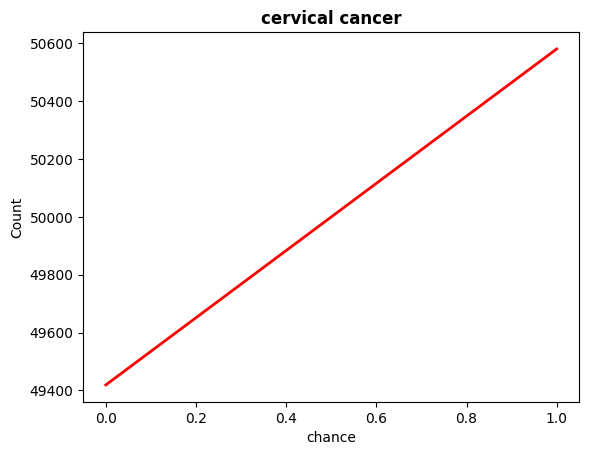

In [ ]:
import matplotlib.pyplot as plt


counts = df["ca_cervix"].value_counts().sort_index()

plt.plot(counts.index, counts.values,color="red",linewidth=2)
plt.title("cervical cancer",fontweight='bold')
plt.xlabel("chance")
plt.ylabel("Count")

plt.show()

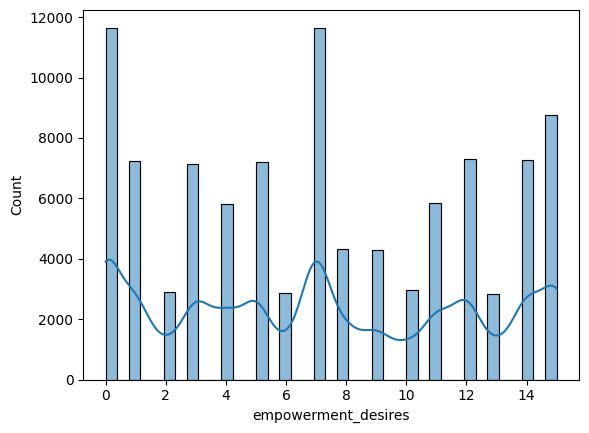

In [ ]:
sns.histplot(df['empowerment_desires'],kde=True)
plt.show()

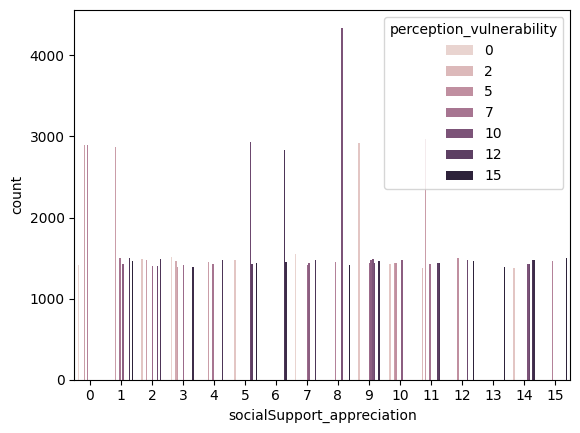

In [ ]:
sns.countplot(data=df, x="socialSupport_appreciation", hue='perception_vulnerability')
plt.show()

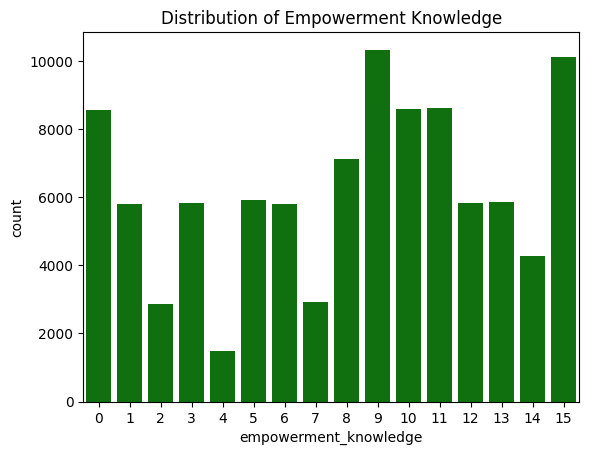

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="empowerment_knowledge", data=df,color="GREEN")
plt.title("Distribution of Empowerment Knowledge")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   behavior_sexualRisk         100000 non-null  int64
 1   behavior_eating             100000 non-null  int64
 2   behavior_personalHygine     100000 non-null  int64
 3   intention_aggregation       100000 non-null  int64
 4   intention_commitment        100000 non-null  int64
 5   attitude_consistency        100000 non-null  int64
 6   attitude_spontaneity        100000 non-null  int64
 7   norm_significantPerson      100000 non-null  int64
 8   norm_fulfillment            100000 non-null  int64
 9   perception_vulnerability    100000 non-null  int64
 10  perception_severity         100000 non-null  int64
 11  motivation_strength         100000 non-null  int64
 12  motivation_willingness      100000 non-null  int64
 13  socialSupport_emotionality  100000 non-null  

**correlation matrix**

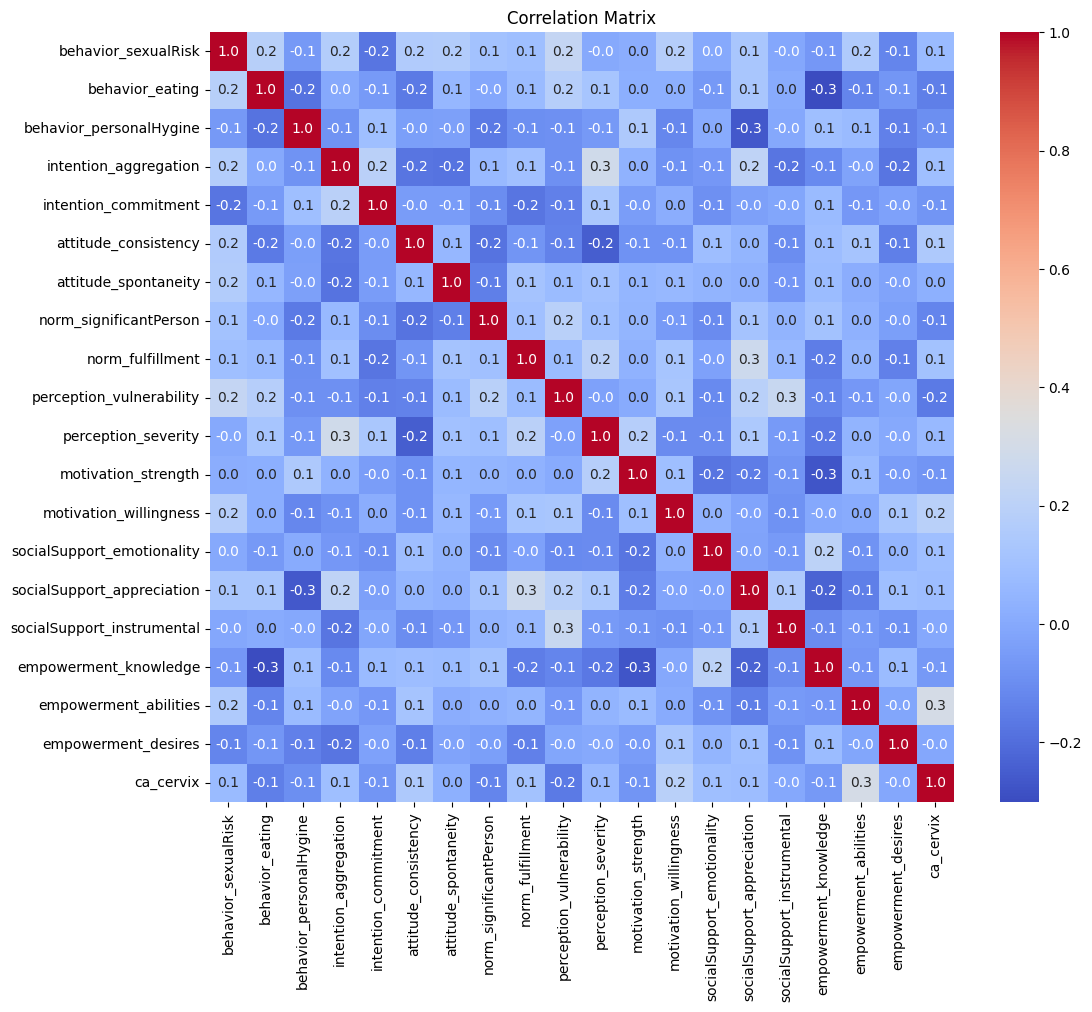

In [ ]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

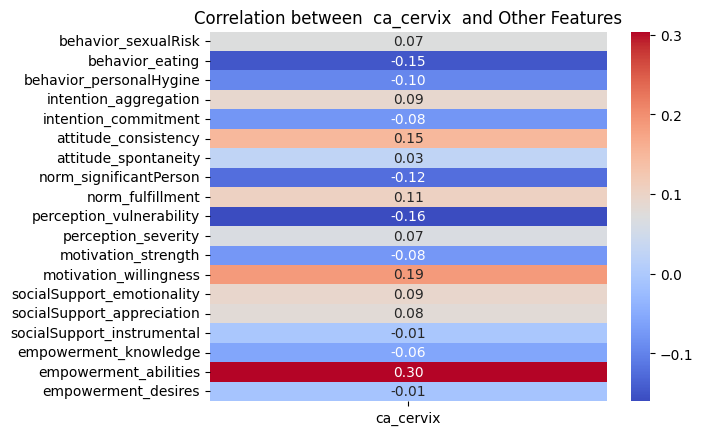

In [ ]:

 ca_cervix_corr = df.corr()['ca_cervix']

 ca_cervix_corr =  ca_cervix_corr.drop('ca_cervix')


sns.heatmap( ca_cervix_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between  ca_cervix  and Other Features')
plt.show()

In [ ]:
df.drop(["behavior_sexualRisk","intention_commitment","attitude_spontaneity","perception_severity","intention_aggregation","motivation_strength","socialSupport_emotionality","socialSupport_appreciation","empowerment_knowledge","empowerment_desires"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   behavior_eating             100000 non-null  int64
 1   behavior_personalHygine     100000 non-null  int64
 2   attitude_consistency        100000 non-null  int64
 3   norm_significantPerson      100000 non-null  int64
 4   norm_fulfillment            100000 non-null  int64
 5   perception_vulnerability    100000 non-null  int64
 6   motivation_willingness      100000 non-null  int64
 7   socialSupport_instrumental  100000 non-null  int64
 8   empowerment_abilities       100000 non-null  int64
 9   ca_cervix                   100000 non-null  int64
dtypes: int64(10)
memory usage: 7.6 MB


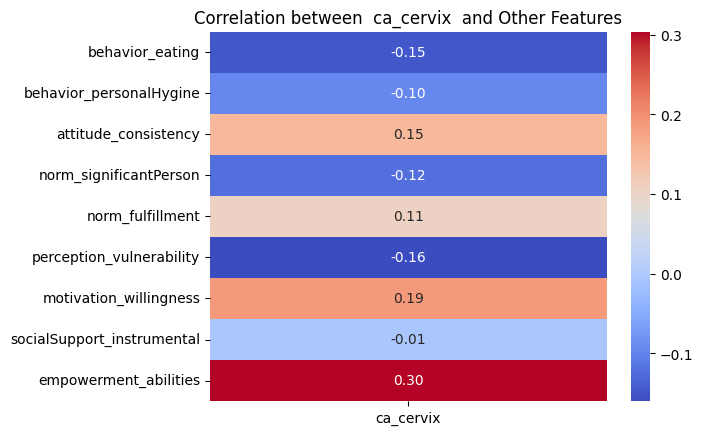

In [ ]:

 ca_cervix_corr = df.corr()['ca_cervix']

 ca_cervix_corr =  ca_cervix_corr.drop('ca_cervix')


sns.heatmap( ca_cervix_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between  ca_cervix  and Other Features')
plt.show()

In [ ]:
df.drop(["socialSupport_instrumental","behavior_personalHygine","norm_fulfillment","norm_significantPerson"],axis=1,inplace=True)

**Outlier checking**

<Axes: >

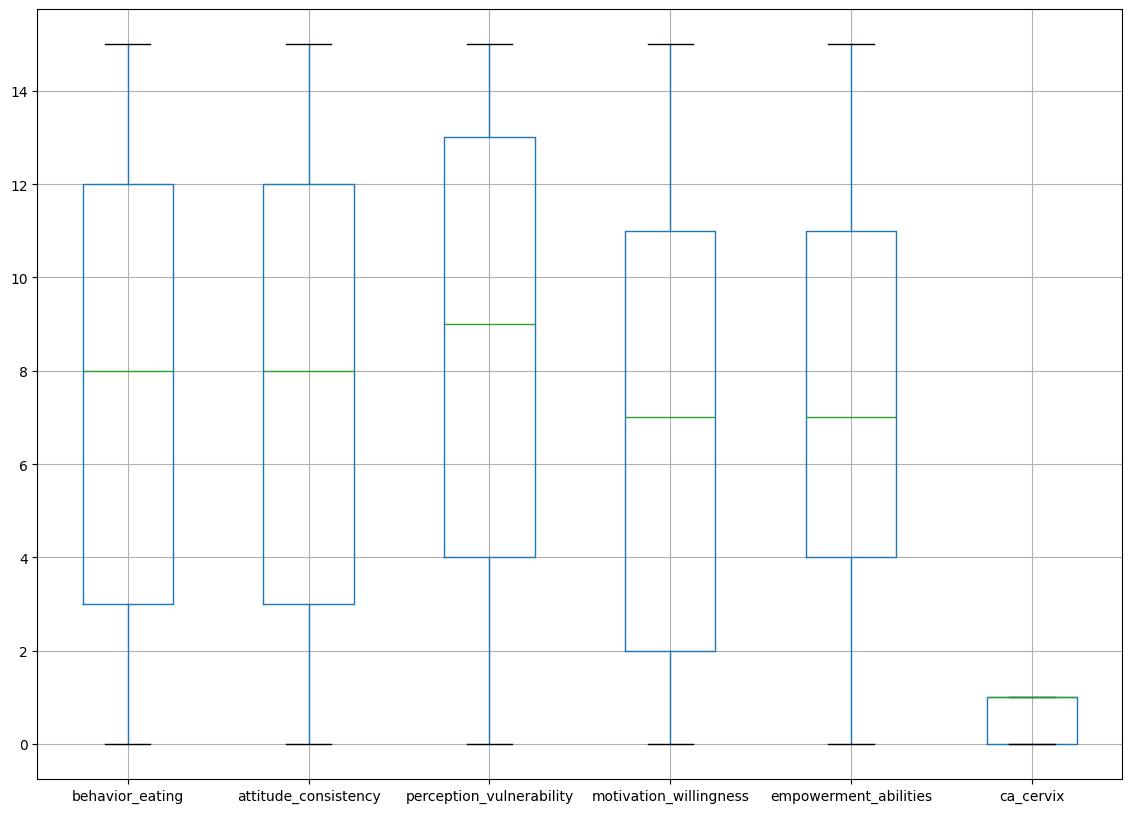

In [ ]:
plt.figure(figsize=(14,10))
df.boxplot()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   behavior_eating           100000 non-null  int64
 1   attitude_consistency      100000 non-null  int64
 2   perception_vulnerability  100000 non-null  int64
 3   motivation_willingness    100000 non-null  int64
 4   empowerment_abilities     100000 non-null  int64
 5   ca_cervix                 100000 non-null  int64
dtypes: int64(6)
memory usage: 4.6 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features = ["behavior_eating","attitude_consistency","perception_vulnerability","motivation_willingness","empowerment_abilities"]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd



X = df[["behavior_eating","attitude_consistency","perception_vulnerability","motivation_willingness","empowerment_abilities"]]
y = df["ca_cervix"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)




model = LogisticRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.71


In [ ]:
df.head(5)

,behavior_eating,attitude_consistency,perception_vulnerability,motivation_willingness,empowerment_abilities,ca_cervix
0,8,13,4,0,14,0
1,11,2,7,0,6,0
2,1,5,4,9,9,0
3,3,3,13,13,1,0
4,4,14,11,2,15,1


In [ ]:
model.predict([[4,14,11,2,15]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 1.00


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train, y_train)
svclassifier.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.39432

In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.70984
Fold 2 Accuracy: 0.71056
Fold 3 Accuracy: 0.69328
Fold 4 Accuracy: 0.694
Fold 5 Accuracy: 0.70952
Fold 6 Accuracy: 0.69696
Fold 7 Accuracy: 0.71264
Fold 8 Accuracy: 0.70056

 Best Fold: 7 with Accuracy: 0.71264


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.71264

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

1.0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

1.0

**DL**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_dl = df.drop("ca_cervix", axis=1)
y_dl = df["ca_cervix"]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_dl)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y_dl,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(64,input_shape=(5,),activation='relu'))

model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_X_train,best_y_train,epochs=10, batch_size=32)

Epoch 1/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 1.0000 - loss: 9.1606e-09
Epoch 2/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 1.0000 - loss: 9.0799e-09
Epoch 3/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 9.1508e-09
Epoch 4/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 1.0000 - loss: 8.9607e-09
Epoch 5/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 1.0000 - loss: 9.1271e-09
Epoch 6/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 1.0000 - loss: 8.7584e-09
Epoch 7/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 8.9528e-09
Epoch 8/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 1.0000 - loss: 8.8843e-09
Epoch 9/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 8.9896e-09
Epoch 10/10
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 1.0000 - loss: 9.1044e-09


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

1.0

In [ ]:
import pickle
with open("cervical cancer model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/cervical cancer model.pkl","rb") as file:
  load_model=pickle.load(file)

# **conclusion**



> This study successfully developed a machine learning model to predict cervical cancer using behavioral, psychological, social support, motivational, and empowerment-related factors. After preprocessing and analyzing the dataset, multiple classification algorithms were implemented and evaluated. Among them, the best-performing model achieved the highest accuracy, demonstrating strong predictive capability.

The final optimized model was saved in pickle (.pkl) format, enabling easy deployment and future use without retraining. Feature analysis also helped identify the most influential risk factors contributing to cervical cancer prediction.

Overall, the project demonstrates that machine learning techniques can effectively support early risk identification and assist in data-driven decision-making for preventive healthcare strategies.

